In [6]:
%pip install implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.2/650.2 kB 7.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [implicit]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


100%|██████████| 15/15 [00:00<00:00, 108.36it/s]


,Model,RMSE,NDCG@10
0,SLIM (Custom),0.031316,0.225328
1,SLIM (Reference),0.028160,0.483006
2,ALS (Custom),0.029252,0.323559
3,ALS (Reference),0.067975,0.270329


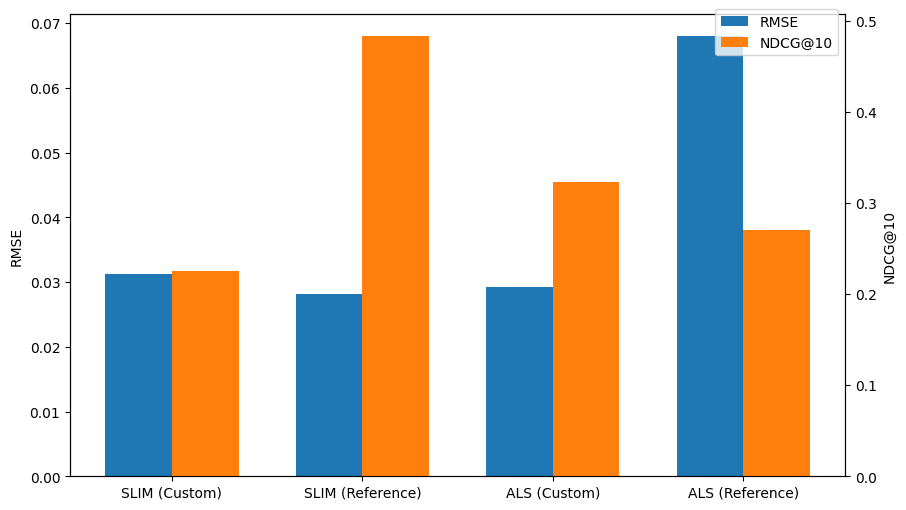

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

from source.slim import CustomSLIM, ReferenceSLIM
from source.als import CustomALS, ReferenceALS
from source.metrics import calculate_rmse, calculate_ndcg

categories = ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'talk.politics.misc']
data = fetch_20newsgroups(subset='train', categories=categories)

vectorizer = TfidfVectorizer(
    stop_words='english',
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    norm='l2',
    max_features=1000
)

R_sparse = vectorizer.fit_transform(data.data)
R = R_sparse.toarray()

slim_custom = CustomSLIM(alpha=0.001, l1_ratio=0.1, epochs=50, lr=0.1)
slim_custom.fit(R)
R_pred_slim_custom = slim_custom.predict(R)

slim_ref = ReferenceSLIM(alpha=0.001, l1_ratio=0.1)
slim_ref.fit(R)
R_pred_slim_ref = slim_ref.predict(R)

als_custom = CustomALS(factors=10, lmbda=0.1, epochs=15)
als_custom.fit(R)
R_pred_als_custom = als_custom.predict()

als_ref = ReferenceALS(factors=10, regularization=0.1, iterations=15)
als_ref.fit(R)
R_pred_als_ref = als_ref.predict()

rmse_slim_custom = calculate_rmse(R, R_pred_slim_custom)
rmse_slim_ref = calculate_rmse(R, R_pred_slim_ref)
rmse_als_custom = calculate_rmse(R, R_pred_als_custom)
rmse_als_ref = calculate_rmse(R, R_pred_als_ref)

ndcg_slim_custom = calculate_ndcg(R, R_pred_slim_custom, k=10)
ndcg_slim_ref = calculate_ndcg(R, R_pred_slim_ref, k=10)
ndcg_als_custom = calculate_ndcg(R, R_pred_als_custom, k=10)
ndcg_als_ref = calculate_ndcg(R, R_pred_als_ref, k=10)

results = pd.DataFrame({
    'Model': ['SLIM (Custom)', 'SLIM (Reference)', 'ALS (Custom)', 'ALS (Reference)'],
    'RMSE': [rmse_slim_custom, rmse_slim_ref, rmse_als_custom, rmse_als_ref],
    'NDCG@10': [ndcg_slim_custom, ndcg_slim_ref, ndcg_als_custom, ndcg_als_ref]
})

results.to_csv('source/results.csv', index=False)
display(results)

fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(results['Model']))
width = 0.35

ax1.bar(x - width/2, results['RMSE'], width, label='RMSE', color='tab:blue')
ax1.set_ylabel('RMSE')
ax1.set_xticks(x)
ax1.set_xticklabels(results['Model'])

ax2 = ax1.twinx()
ax2.bar(x + width/2, results['NDCG@10'], width, label='NDCG@10', color='tab:orange')
ax2.set_ylabel('NDCG@10')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.savefig('source/comparison_plot.png')
plt.show()
